# Exploratory Data Analysis (**EDA**)

## Objetivo:
Explorar la composición del microbioma intestinal, la distribución de condiciones clínicas y posibles sesgos asociados a metadata como país, estudio, edad, género y BMI.

## 0. Importar librerías

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

#PCA del microbioma
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## 1. Cargar datos limpios

In [2]:
df_eda = pd.read_csv("D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/data/processed/abundance_stoolsubset_clean.csv",
    low_memory=False
)

df_eda.shape

(1577, 2135)

## 2. Vista general del dataset

In [3]:
metadata_cols = [
    "dataset_name",
    "sampleID",
    "disease",
    "age",
    "gender",
    "country",
    "bmi"
]

taxa_cols = [col for col in df_eda.columns if col.startswith("k__")]

print("Número de muestras:", df_eda.shape[0])
print("Número de columnas totales:", df_eda.shape[1])
print("Número de columnas metadata:", len(metadata_cols))
print("Número de columnas taxonómicas:", len(taxa_cols))

Número de muestras: 1577
Número de columnas totales: 2135
Número de columnas metadata: 7
Número de columnas taxonómicas: 2128


In [4]:
df_eda[metadata_cols].isna().sum().sort_values(ascending=False)

age             356
bmi             331
dataset_name      0
disease           0
sampleID          0
gender            0
country           0
dtype: int64

In [5]:
df_eda["sampleID"].duplicated().sum()

np.int64(0)

In [6]:
df_eda["disease"].value_counts(dropna=False)

disease
n                             710
t2d                           223
ibd_ulcerative_colitis        148
cirrhosis                     118
obesity                        75
impaired_glucose_tolerance     49
cancer                         48
n_relative                     47
stec2-positive                 43
leanness                       42
small_adenoma                  26
ibd_crohn_disease              25
large_adenoma                  13
overweight                     10
Name: count, dtype: int64

El dataset limpio contiene **1577 muestras únicas**, sin sampleID duplicados y con **2128 variables taxonómicas**. La variable `disease` no presenta valores nulos, aunque `age` y `bmi` conservan valores faltantes, por lo que inicialmente se utilizarán como **variables descriptivas** y no como predictores principales.

## 3. Distribución de las enfermedades

In [7]:
# Conteo y porcentaje por enfermedad
disease_counts = df_eda["disease"].value_counts().sort_values(ascending=False)
disease_percentages = disease_counts / disease_counts.sum() * 100

In [8]:
# DataFrame - conteo y porcentaje por enfermedad
disease_distribution = pd.DataFrame({
    "count": disease_counts,
    "percentage": disease_percentages.round(2)
})

disease_distribution

,count,percentage
disease,,
n,710,45.02
t2d,223,14.14
ibd_ulcerative_colitis,148,9.38
cirrhosis,118,7.48
obesity,75,4.76
impaired_glucose_tolerance,49,3.11
cancer,48,3.04
n_relative,47,2.98
stec2-positive,43,2.73


In [9]:
### Paleta de colores

# Paleta general del proyecto
project_palette = {
    "primary": "#2F5D62",
    "secondary": "#5E8B7E",
    "accent": "#D88C3A",
    "danger": "#B85750",
    "neutral": "#6B7280",
    "light": "#F3F4F6",
    "dark": "#1F2937"
}

# Paleta específica para "disease"
disease_palette = {
    "n": "#2F5D62",
    "t2d": "#D88C3A",
    "ibd_ulcerative_colitis": "#7A5195",
    "cirrhosis": "#B85750",
    "obesity": "#5E8B7E",
    "impaired_glucose_tolerance": "#E0A458",
    "cancer": "#4C78A8",
    "n_relative": "#8C8C8C",
    "stec2-positive": "#C44E52",
    "leanness": "#76B7B2",
    "small_adenoma": "#9C755F",
    "ibd_crohn_disease": "#59A14F",
    "large_adenoma": "#AF7AA1",
    "overweight": "#F28E2B"
}

C:\Users\gonza\AppData\Local\Temp\ipykernel_20088\3968542494.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


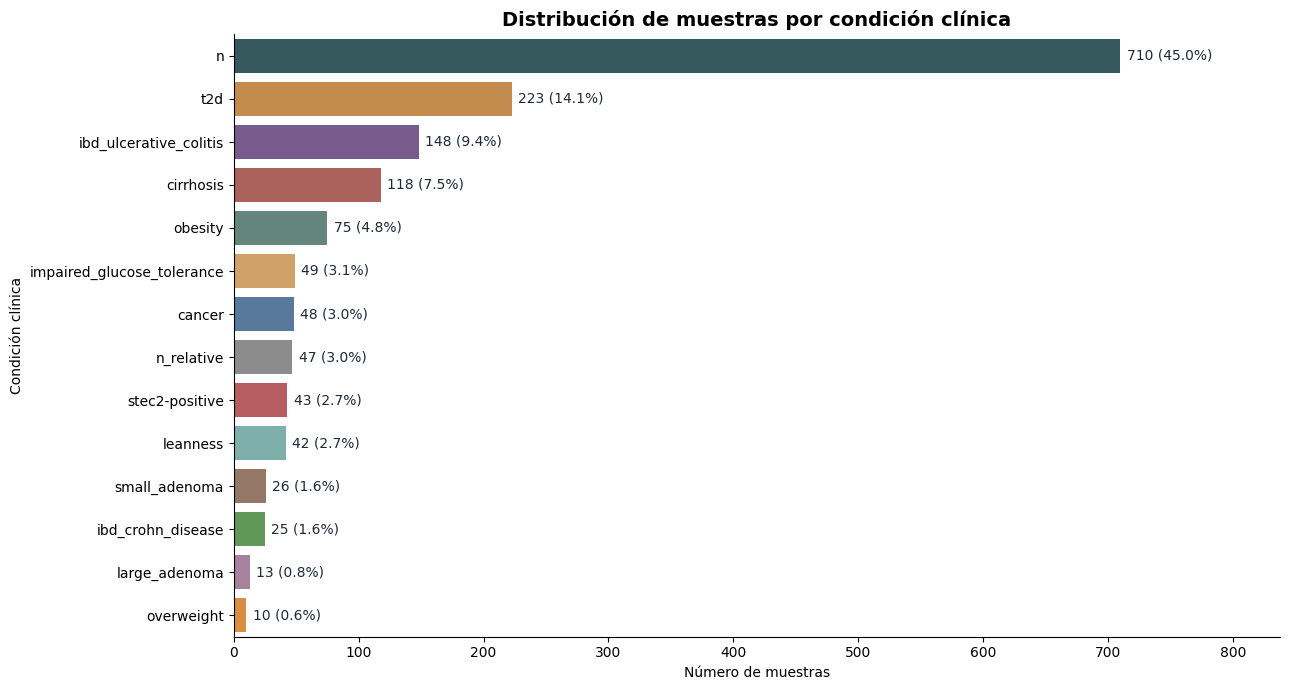

In [10]:
## Gráfico de barras - distribución de enfermedades
plt.figure(figsize=(13, 7))

bar_colors = [
    disease_palette.get(disease, project_palette["neutral"])
    for disease in disease_counts.index
]

ax = sns.barplot(
    x=disease_counts.values,
    y=disease_counts.index,
    palette=bar_colors
)

for i, (count, pct) in enumerate(zip(disease_counts.values, disease_percentages.values)):
    ax.text(
        count + 5,
        i,
        f"{count} ({pct:.1f}%)",
        va="center",
        fontsize=10,
        color=project_palette["dark"]
    )

plt.title("Distribución de muestras por condición clínica", fontsize=14, fontweight="bold")
plt.xlabel("Número de muestras")
plt.ylabel("Condición clínica")
plt.xlim(0, disease_counts.max() * 1.18)

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/muestra_condicion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

La variable `disease` presenta una distribución desbalanceada. 
<br>
La clase mayoritaria es `n`, correspondiente a controles, seguida por `t2d`, `ibd_ulcerative_colitis`, `cirrhosis` y `obesity`.
<br>
Algunas categorías tienen muy pocas muestras, como `large_adenoma` y `overweight`, por lo que se conservarán para EDA general pero no se consideran candidatas principales para el modelado supervisado inicial.

## 4. Análisis de metadata clínica

### 4.1. Distribución de metadata clínica: `age` y `bmi`

In [11]:
numeric_metadata = ["age", "bmi"]

df_eda[numeric_metadata].describe()

,age,bmi
count,1221.000000,1246.000000
mean,48.964955,24.534551
std,16.445743,4.665831
min,2.000000,14.050000
25%,37.000000,21.000000
50%,49.000000,24.000000
75%,63.000000,26.875000
max,89.000000,46.600000


In [12]:
# Porcentaje de valores nulos en "age" y "bmi"
missing_numeric_metadata = (
    df_eda[numeric_metadata]
    .isna()
    .mean()
    .mul(100)
    .round(2)
)

missing_numeric_metadata

age    22.57
bmi    20.99
dtype: float64

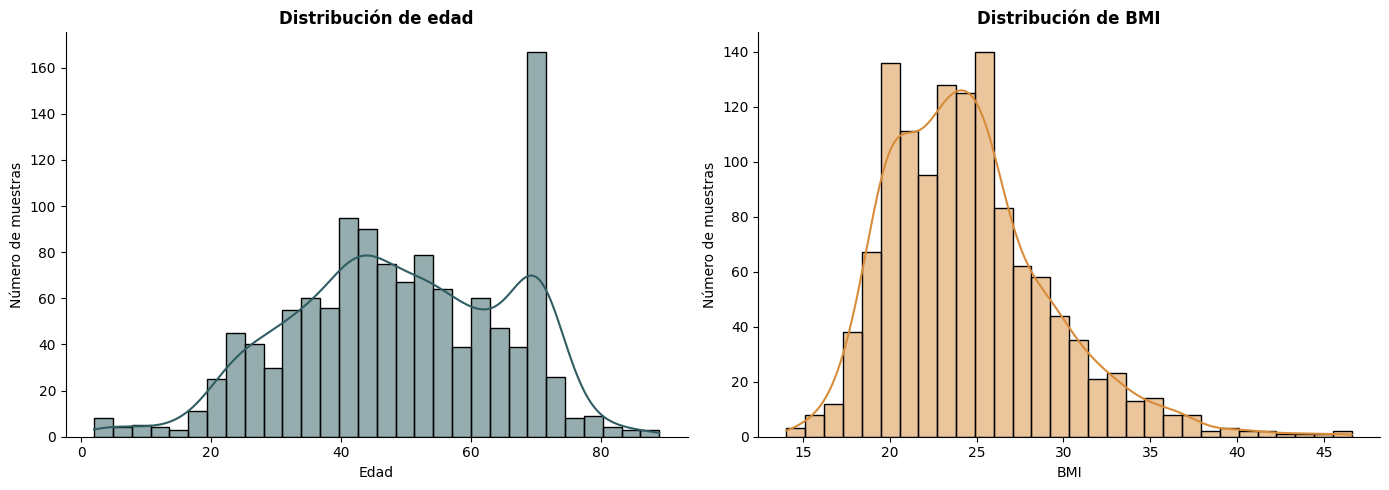

In [13]:
# Distribución general de "age" y "bmi"
fig, axes = plt.subplots(1, 2, figsize=(14, 5))     # dos gráficos en una fila

# Age
sns.histplot(
    data=df_eda,
    x="age",
    bins=30,        # 30 grupos
    kde=True,       # curva suave de densidad
    color=project_palette["primary"],
    ax=axes[0]
)

axes[0].set_title("Distribución de edad", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Número de muestras")

# BMI
sns.histplot(
    data=df_eda,
    x="bmi",
    bins=30,
    kde=True,
    color=project_palette["accent"],
    ax=axes[1]
)

axes[1].set_title("Distribución de BMI", fontsize=12, fontweight="bold")
axes[1].set_xlabel("BMI")
axes[1].set_ylabel("Número de muestras")

sns.despine()       # quit alos bordes visuales del gráfico
plt.tight_layout()  # evita que los textos y ejes se monten

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/distr_edad_bmi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
# Filtrar enfermedades con al menos 10 valores válidos de age

min_age_values = 10

valid_age_counts = df_eda.groupby("disease")["age"].count()

diseases_with_age = valid_age_counts[
    valid_age_counts >= min_age_values
].index

df_age_boxplot = df_eda[
    df_eda["disease"].isin(diseases_with_age)
].copy()

In [15]:
# Orden alfabético
age_order = sorted(df_age_boxplot["disease"].unique())

C:\Users\gonza\AppData\Local\Temp\ipykernel_20088\3620942095.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


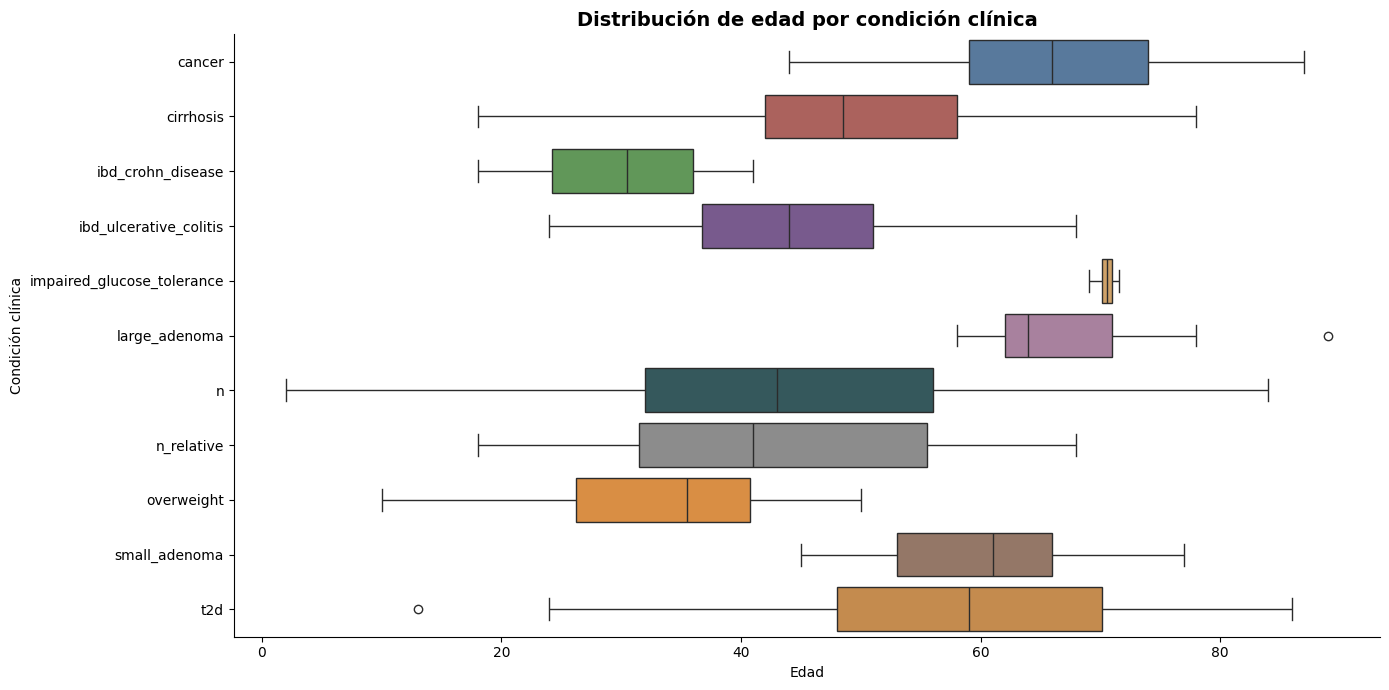

In [16]:
## Boxplot de edad por enfermedad
plt.figure(figsize=(14, 7))

bar_colors = [
    disease_palette.get(disease, project_palette["neutral"])
    for disease in age_order
]

sns.boxplot(
    data=df_age_boxplot,
    x="age",
    y="disease",
    order=age_order,
    palette=bar_colors
)

plt.title("Distribución de edad por condición clínica", fontsize=14, fontweight="bold")
plt.xlabel("Edad")
plt.ylabel("Condición clínica")

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/edad_condicion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
# Filtrar enfermedades con al menos 10 valores válidos de BMI

min_bmi_values = 10

valid_bmi_counts = df_eda.groupby("disease")["bmi"].count()

diseases_with_bmi = valid_bmi_counts[
    valid_bmi_counts >= min_bmi_values
].index

df_bmi_boxplot = df_eda[
    df_eda["disease"].isin(diseases_with_bmi)
].copy()

In [18]:
# Orden alfabético
bmi_order = sorted(df_bmi_boxplot["disease"].unique())


C:\Users\gonza\AppData\Local\Temp\ipykernel_20088\2353784519.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


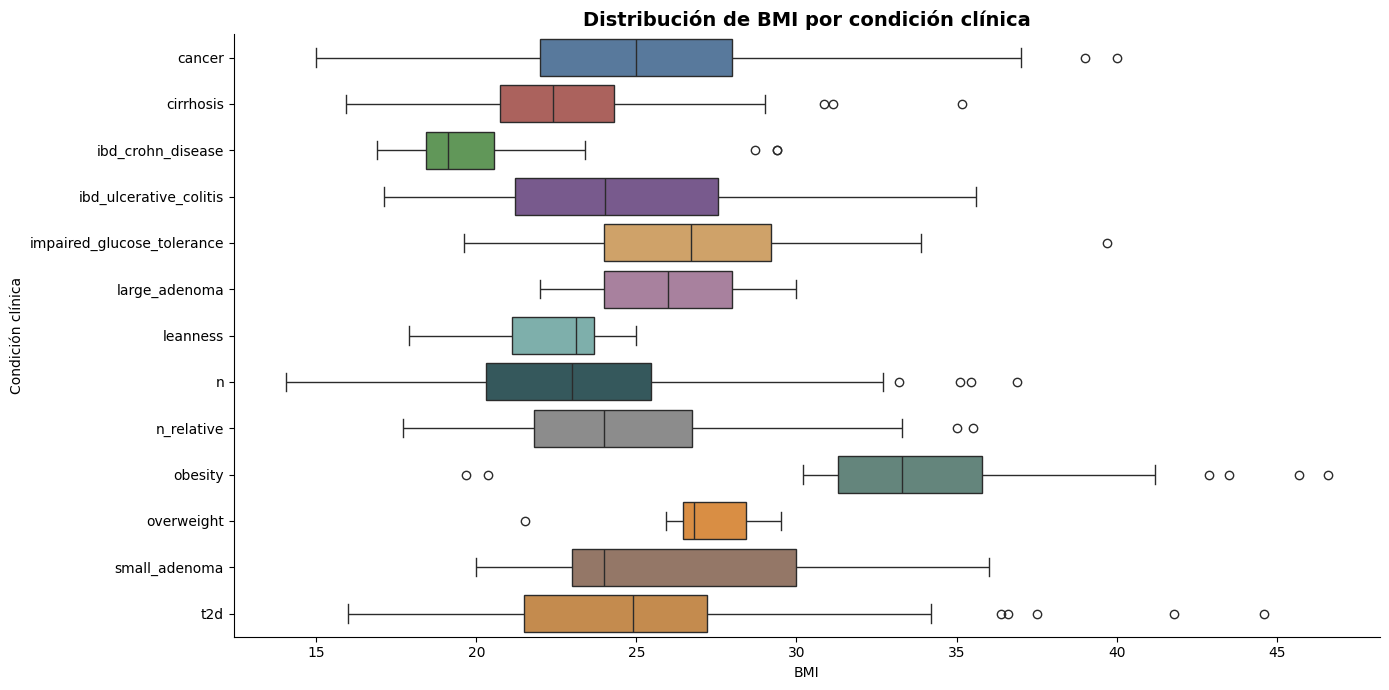

In [19]:
## Boxplot de BMI por enfermedad
plt.figure(figsize=(14, 7))

bar_colors = [
    disease_palette.get(disease, project_palette["neutral"])
    for disease in bmi_order
]

sns.boxplot(
    data=df_bmi_boxplot,
    x="bmi",
    y="disease",
    order=bmi_order,
    palette=bar_colors
)

plt.title("Distribución de BMI por condición clínica", fontsize=14, fontweight="bold")
plt.xlabel("BMI")
plt.ylabel("Condición clínica")

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/bmi_condicion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Distribución de metadata categórica

### 5.1. Distribución de metadata categórica: `gender`

In [20]:
# Conteo de muestras por categoria de "gender" (male/female/unknown)
gender_counts = df_eda["gender"].value_counts()

# Porcentaje que representa cada categoría
gender_percentages = gender_counts / gender_counts.sum() * 100

# DataFrame - conteo y porcentaje
gender_distribution = pd.DataFrame({
    "count": gender_counts,
    "percentage": gender_percentages.round(2)
})

gender_distribution

,count,percentage
gender,,
male,688,43.63
female,585,37.10
unknown,304,19.28


In [21]:
# Paleta de colores
gender_palette = {
    "female": "#2F5D62",
    "male": "#D88C3A",
    "unknown": "#8C8C8C"
}

C:\Users\gonza\AppData\Local\Temp\ipykernel_20088\3367694956.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


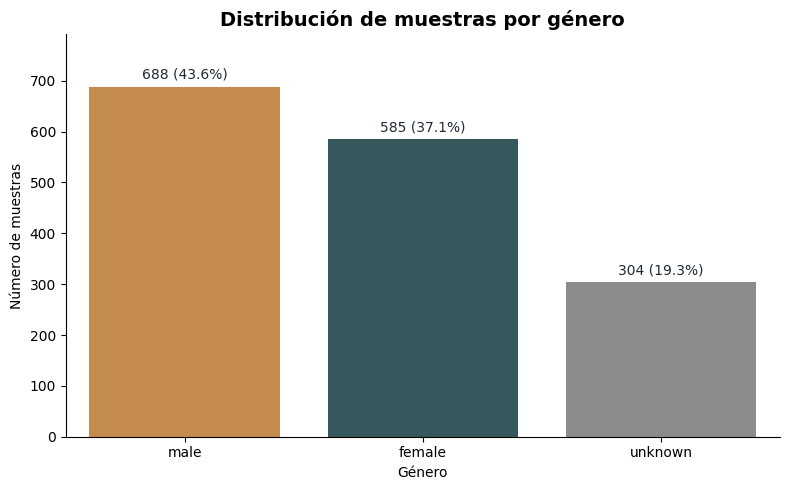

In [22]:
# Gráfico
plt.figure(figsize=(8, 5))

bar_colors = [
    gender_palette.get(gender, project_palette["neutral"])
    for gender in gender_counts.index
]

ax = sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values,
    palette=bar_colors
)

for i, (count, pct) in enumerate(zip(gender_counts.values, gender_percentages.values)):
    ax.text(
        i,
        count + 10,
        f"{count} ({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        color=project_palette["dark"]
    )

plt.title("Distribución de muestras por género", fontsize=14, fontweight="bold")
plt.xlabel("Género")
plt.ylabel("Número de muestras")
plt.ylim(0, gender_counts.max() * 1.15)

sns.despine()
plt.tight_layout()

plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/genero_distr",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 5.2. Distribución de metadata categórica: `country`

In [23]:
# Distribución por país: top 10 + "other" + "unknown"

country_counts = df_eda["country"].value_counts()

# Seleccionar top 10 países, excluyendo "unknown"
top_n_countries = 10

top_countries = (
    country_counts
    .drop(labels="unknown", errors="ignore")
    .head(top_n_countries)
    .index
    .tolist()
)

# Crear una columna auxiliar para el gráfico
df_eda["country_plot"] = df_eda["country"].where(
    df_eda["country"].isin(top_countries),
    "other"
)

# Mantener "unknown" separado, no dentro de "other"
df_eda.loc[df_eda["country"] == "unknown", "country_plot"] = "unknown"

# Conteos y porcentajes
country_plot_counts = df_eda["country_plot"].value_counts()

# Orden manual: top 10 países, luego "other", luego "unknown"
country_order = top_countries.copy()

if "other" in country_plot_counts.index:
    country_order.append("other")

if "unknown" in country_plot_counts.index:
    country_order.append("unknown")

country_plot_counts = country_plot_counts.loc[country_order]
country_plot_percentages = country_plot_counts / country_plot_counts.sum() * 100

In [24]:
# Paleta para países
country_palette_base = [
    project_palette["primary"],
    project_palette["secondary"],
    "#4C78A8",
    "#7A5195",
    "#76B7B2",
    "#E0A458",
    "#9C755F",
    "#59A14F",
    "#AF7AA1",
    "#F28E2B"
]

country_palette = {
    country: color
    for country, color in zip(top_countries, country_palette_base)
}

country_palette["other"] = project_palette["accent"]
country_palette["unknown"] = "#9CA3AF"

bar_colors = [
    country_palette.get(country, project_palette["neutral"])
    for country in country_plot_counts.index
]

C:\Users\gonza\AppData\Local\Temp\ipykernel_20088\2596293868.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


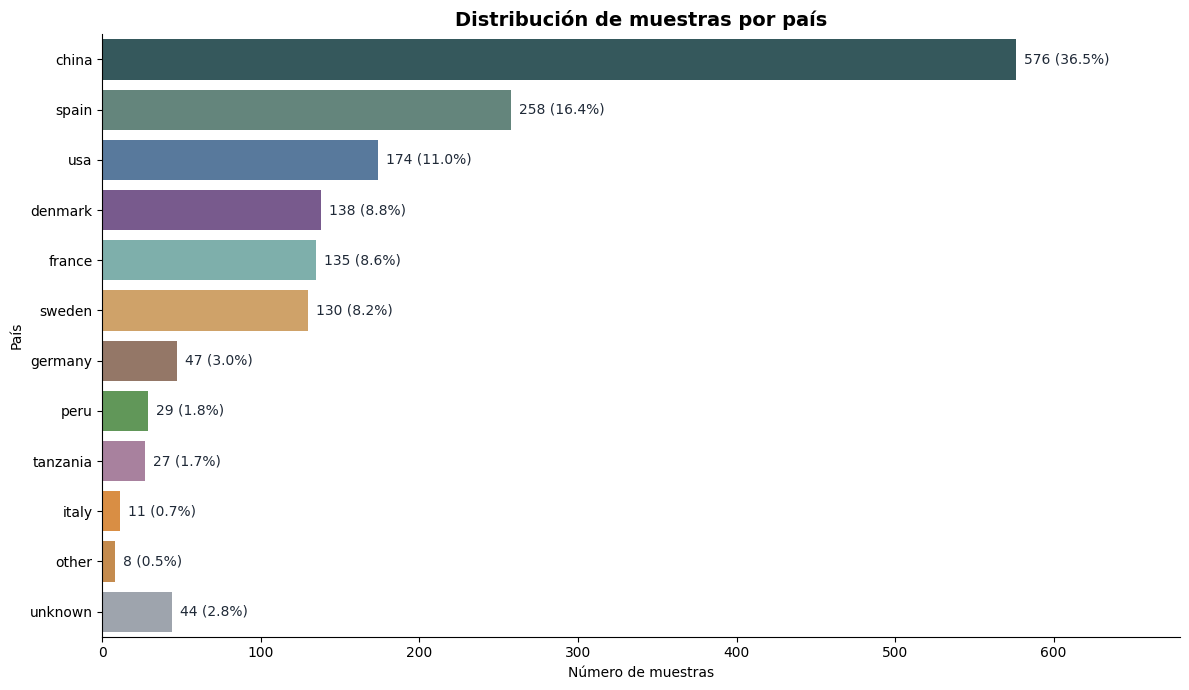

In [25]:
# Gráfico
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    x=country_plot_counts.values,
    y=country_plot_counts.index,
    palette=bar_colors
)

for i, (count, pct) in enumerate(zip(country_plot_counts.values, country_plot_percentages.values)):
    ax.text(
        count + 5,
        i,
        f"{count} ({pct:.1f}%)",
        va="center",
        fontsize=10,
        color=project_palette["dark"]
    )

plt.title("Distribución de muestras por país", fontsize=14, fontweight="bold")
plt.xlabel("Número de muestras")
plt.ylabel("País")
plt.xlim(0, country_plot_counts.max() * 1.18)

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/country_distr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 5.3. Distribución de metadata categórica: `dataset_name`

Observar si el dataset está dominado por ciertos estudios. Y eso importa muchísimo, porque si luego el PCA o el modelo separan por `dataset_name`, puede haber sesgo de origen.

In [26]:
# Distribución por dataset de origen

# Contar cuántas muestras vienen de cada "dataset_name"
dataset_counts = df_eda["dataset_name"].value_counts()

# Calcular porcentaje
dataset_percentages = dataset_counts / dataset_counts.sum() * 100

# Top 20 estudios/datasets principales
dataset_distribution = pd.DataFrame({
    "count": dataset_counts,
    "percentage": dataset_percentages.round(2)
})

dataset_distribution.head(20)

,count,percentage
dataset_name,,
t2dmeta_long,271,17.18
quin_gut_liver_cirrhosis,232,14.71
neilsen_genome_assembly,231,14.65
hmp,152,9.64
wt2d,145,9.19
zeller_fecal_colorectal_cancer,134,8.50
chatelier_gut_obesity,115,7.29
t2dmeta_short,73,4.63
tito_subsistence_gut,51,3.23


In [27]:
# Seleccionar los 10 datasets con más muestras
top_n_datasets = 10

top_datasets = dataset_counts.head(top_n_datasets).index.tolist()

df_eda["dataset_plot"] = df_eda["dataset_name"].where(
    df_eda["dataset_name"].isin(top_datasets),
    "other"
)

dataset_plot_counts = df_eda["dataset_plot"].value_counts()

dataset_order = top_datasets.copy()

if "other" in dataset_plot_counts.index:
    dataset_order.append("other")

dataset_plot_counts = dataset_plot_counts.loc[dataset_order]
dataset_plot_percentages = dataset_plot_counts / dataset_plot_counts.sum() * 100

C:\Users\gonza\AppData\Local\Temp\ipykernel_20088\1421550921.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


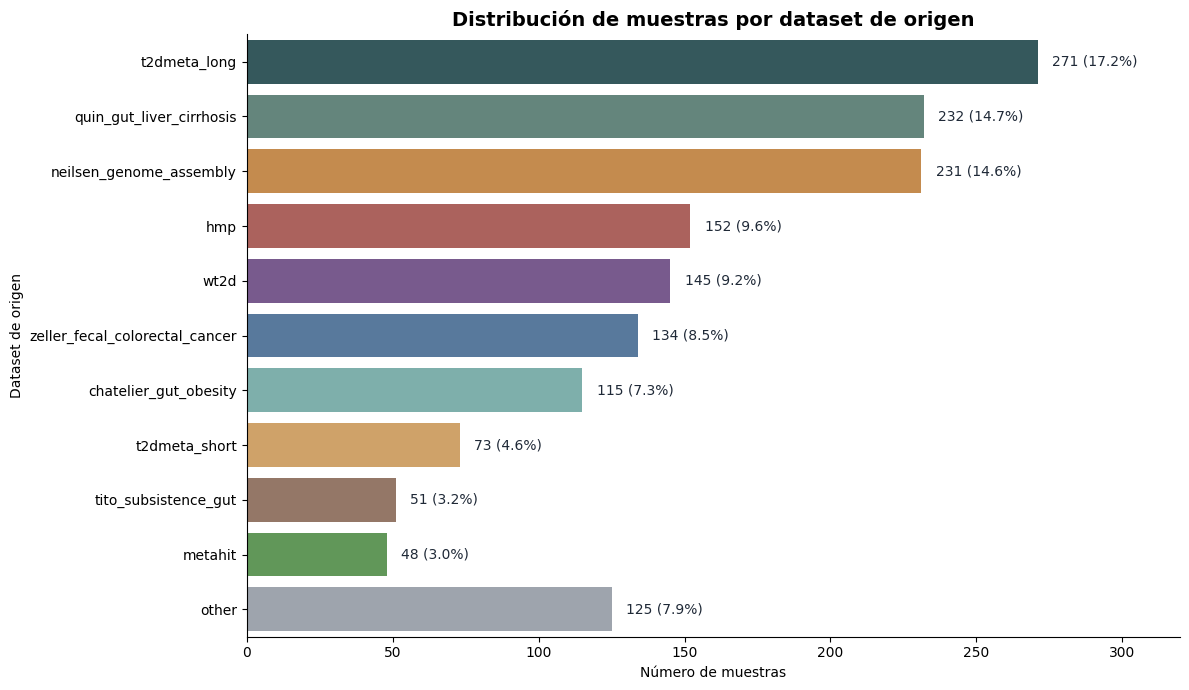

In [28]:
# Gráfico
dataset_palette_base = [
    project_palette["primary"],
    project_palette["secondary"],
    project_palette["accent"],
    project_palette["danger"],
    "#7A5195",
    "#4C78A8",
    "#76B7B2",
    "#E0A458",
    "#9C755F",
    "#59A14F"
]

dataset_palette = {
    dataset: color
    for dataset, color in zip(top_datasets, dataset_palette_base)
}

dataset_palette["other"] = "#9CA3AF"

bar_colors = [
    dataset_palette.get(dataset, project_palette["neutral"])
    for dataset in dataset_plot_counts.index
]

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    x=dataset_plot_counts.values,
    y=dataset_plot_counts.index,
    palette=bar_colors
)

for i, (count, pct) in enumerate(zip(dataset_plot_counts.values, dataset_plot_percentages.values)):
    ax.text(
        count + 5,
        i,
        f"{count} ({pct:.1f}%)",
        va="center",
        fontsize=10,
        color=project_palette["dark"]
    )

plt.title("Distribución de muestras por dataset de origen", fontsize=14, fontweight="bold")
plt.xlabel("Número de muestras")
plt.ylabel("Dataset de origen")
plt.xlim(0, dataset_plot_counts.max() * 1.18)

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/dataset_origin_distr_top10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6. Análisis general de taxones

### 6.1. Análisis general de taxones

In [29]:
# Contar número de columnas taxonómicas
taxa_cols = [col for col in df_eda.columns if col.startswith("k__")]

print("Número de columnas taxonómicas:", len(taxa_cols))

Número de columnas taxonómicas: 2128


In [30]:
# Identificar niveles taxonómicos
def get_deepest_taxonomic_level(taxon_name):
    levels = taxon_name.split("|")
    deepest_level = levels[-1]
    return deepest_level.split("__")[0] + "__"

taxonomic_levels = pd.Series(
    [get_deepest_taxonomic_level(col) for col in taxa_cols]
)

taxonomic_level_counts = taxonomic_levels.value_counts()

taxonomic_level_counts

s__    826
t__    767
g__    292
f__    119
o__     60
c__     38
p__     23
k__      3
Name: count, dtype: int64

In [31]:
# Definir paleta de colores
taxonomic_level_palette = {
    "k__": "#2F5D62",
    "p__": "#5E8B7E",
    "c__": "#76B7B2",
    "o__": "#4C78A8",
    "f__": "#7A5195",
    "g__": "#D88C3A",
    "s__": "#B85750",
    "t__": "#9C755F"
}

C:\Users\gonza\AppData\Local\Temp\ipykernel_20088\2810565461.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


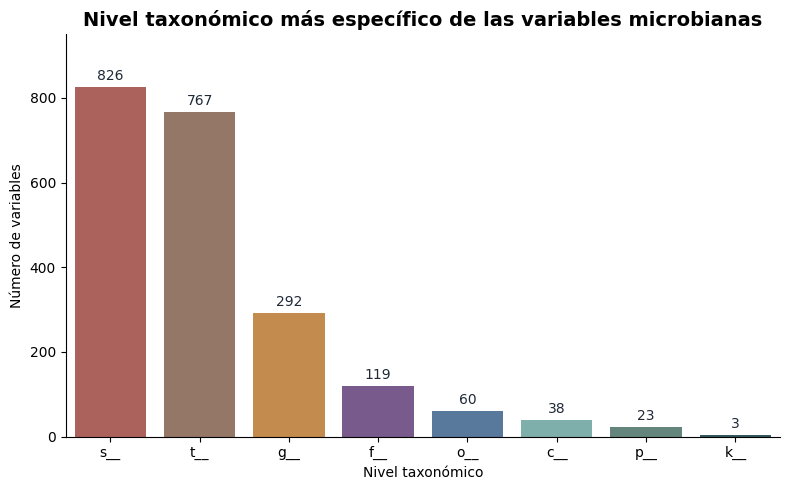

In [32]:
# Graficar niveles taxonómicos
plt.figure(figsize=(8, 5))

bar_colors = [
    taxonomic_level_palette.get(level, project_palette["neutral"])
    for level in taxonomic_level_counts.index
]

ax = sns.barplot(
    x=taxonomic_level_counts.index,
    y=taxonomic_level_counts.values,
    palette=bar_colors
)

for i, count in enumerate(taxonomic_level_counts.values):
    ax.text(
        i,
        count + 10,
        str(count),
        ha="center",
        va="bottom",
        fontsize=10,
        color=project_palette["dark"]
    )

plt.title("Nivel taxonómico más específico de las variables microbianas", fontsize=14, fontweight="bold")
plt.xlabel("Nivel taxonómico")
plt.ylabel("Número de variables")
plt.ylim(0, taxonomic_level_counts.max() * 1.15)

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/niveles_taxonomicos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 6.2. *Sparsity* de las variables taxonómicas

**Sparsity**: condición en la que un conjunto de datos, una matriz o un modelo contiene una gran cantidad de elementos vacíos, nulos o con valor de cero.
<br>
En este caso en particular, revisar cuántos ceros hay en las **abundancias**.

In [33]:
# Sparsity de las variables taxonómicas

X_taxa = df_eda[taxa_cols]      # dataframe solo con taxones

zero_percentage_by_taxon = (X_taxa == 0).mean().mul(100)        # máscara

zero_percentage_by_taxon.describe()

count    2128.000000
mean       86.851700
std        24.461694
min         0.000000
25%        89.109068
50%        98.858592
75%        99.873177
max       100.000000
dtype: float64

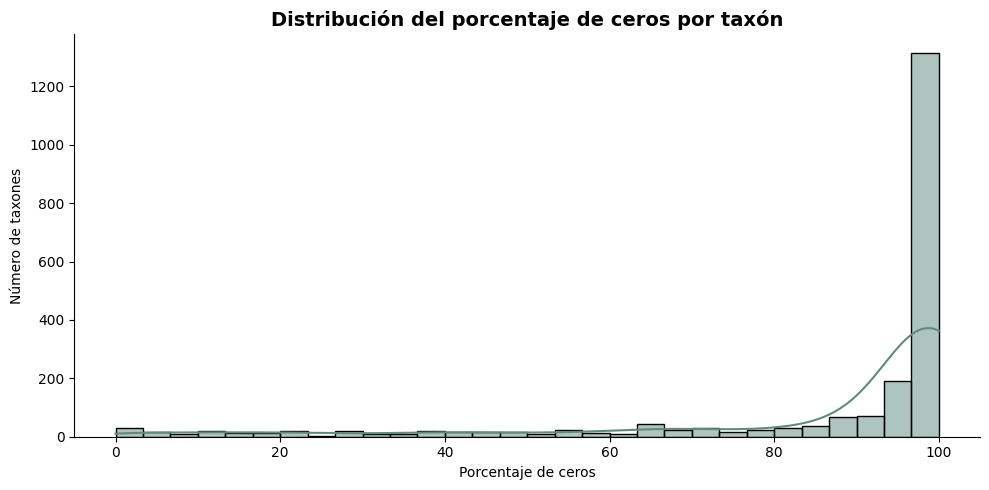

In [34]:
# Gráfico
plt.figure(figsize=(10, 5))

sns.histplot(
    zero_percentage_by_taxon,
    bins=30,
    kde=True,
    color=project_palette["secondary"]
)

plt.title("Distribución del porcentaje de ceros por taxón", fontsize=14, fontweight="bold")
plt.xlabel("Porcentaje de ceros")
plt.ylabel("Número de taxones")

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/sparsity_taxones.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

La distribución muestra una elevada sparsity en las variables taxonómicas: muchos taxones tienen valores cero en más del 90-95% de las muestras. Esto indica que gran parte de los taxones son poco prevalentes en la cohorte analizada. Esta característica es habitual en datos de microbioma y justifica aplicar estrategias posteriores de filtrado de baja prevalencia, agregación taxonómica o reducción de dimensionalidad antes del modelado.

### 6.3. Prevalencia de taxones según distintos umbrales

Cuantificar cuántos taxones conservar con distintos umbrales de prevalencia. Sirve para decidir después si es necesario filtrar.

In [39]:
# Calcula en qué % de muestras aparece cada taxón
prevalence_by_taxon = (X_taxa > 0).mean().mul(100)

# Define posibles umbrales
prevalence_thresholds = [1, 5, 10, 20, 30, 50]

prevalence_filter_summary = pd.DataFrame({
    "prevalence_threshold_pct": prevalence_thresholds,
    "taxa_retained": [
        (prevalence_by_taxon >= threshold).sum()
        for threshold in prevalence_thresholds
    ]
})

prevalence_filter_summary

,prevalence_threshold_pct,taxa_retained
0,1,1107
1,5,713
2,10,555
3,20,420
4,30,349
5,50,227


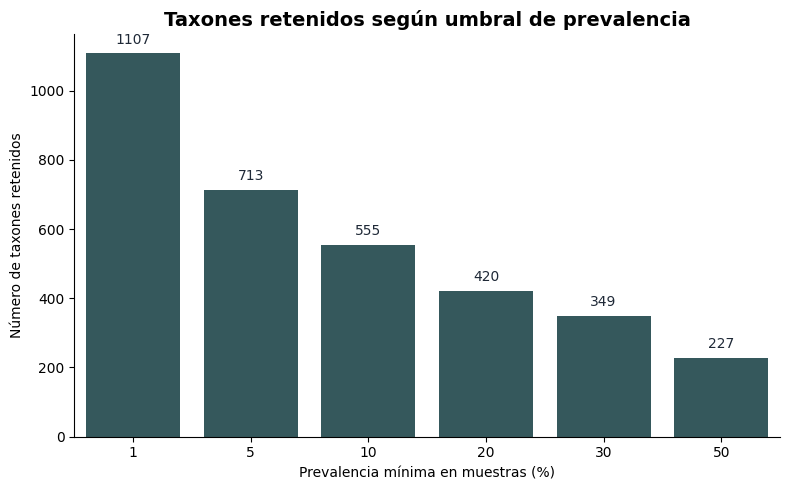

In [40]:
#Graficar
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=prevalence_filter_summary,
    x="prevalence_threshold_pct",
    y="taxa_retained",
    color=project_palette["primary"]
)

for i, row in prevalence_filter_summary.iterrows():
    ax.text(
        i,
        row["taxa_retained"] + 20,
        int(row["taxa_retained"]),
        ha="center",
        va="bottom",
        fontsize=10,
        color=project_palette["dark"]
    )

plt.title("Taxones retenidos según umbral de prevalencia", fontsize=14, fontweight="bold")
plt.xlabel("Prevalencia mínima en muestras (%)")
plt.ylabel("Número de taxones retenidos")

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/taxones_retenidos_prevalencia.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 6.4. Taxones más abundantes

In [41]:
# Calcular la abundancia media de cada taxon en todas las muestras (y ordenar de mayor a menor)
mean_abundance_by_taxon = X_taxa.mean().sort_values(ascending=False)

# Top 20
top_n_taxa = 20

top_abundant_taxa = mean_abundance_by_taxon.head(top_n_taxa)

top_abundant_taxa

k__Bacteria                                                                                                                          99.197602
k__Bacteria|p__Firmicutes                                                                                                            45.145436
k__Bacteria|p__Bacteroidetes                                                                                                         44.546800
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales                                                                         44.537093
k__Bacteria|p__Bacteroidetes|c__Bacteroidia                                                                                          44.537093
k__Bacteria|p__Firmicutes|c__Clostridia                                                                                              37.954407
k__Bacteria|p__Firmicutes|c__Clostridia|o__Clostridiales                                                                             37.954366

In [42]:
# Función para editar el nombre de los taxones
def simplify_taxon_name(taxon_name):
    parts = taxon_name.split("|")
    deepest_part = parts[-1]
    return deepest_part

In [43]:
top_abundant_taxa_plot = pd.DataFrame({
    "taxon": top_abundant_taxa.index,
    "mean_abundance": top_abundant_taxa.values
})

top_abundant_taxa_plot["taxon_short"] = top_abundant_taxa_plot["taxon"].apply(
    simplify_taxon_name
)

top_abundant_taxa_plot

,taxon,mean_abundance,taxon_short
0,k__Bacteria,99.197602,k__Bacteria
1,k__Bacteria|p__Firmicutes,45.145436,p__Firmicutes
2,k__Bacteria|p__Bacteroidetes,44.546800,p__Bacteroidetes
3,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o_...,44.537093,o__Bacteroidales
4,k__Bacteria|p__Bacteroidetes|c__Bacteroidia,44.537093,c__Bacteroidia
5,k__Bacteria|p__Firmicutes|c__Clostridia,37.954407,c__Clostridia
6,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,37.954366,o__Clostridiales
7,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o_...,27.217505,f__Bacteroidaceae
8,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o_...,27.217505,g__Bacteroides
9,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,16.679208,f__Ruminococcaceae


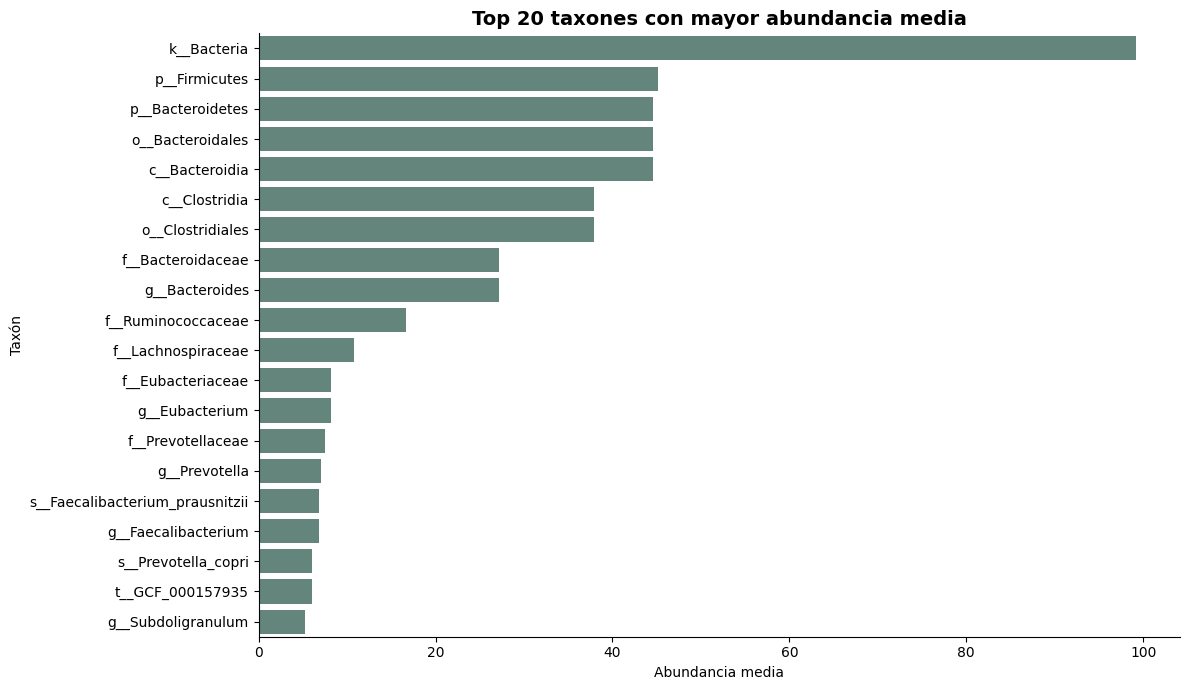

In [44]:
# Graficar
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top_abundant_taxa_plot,
    x="mean_abundance",
    y="taxon_short",
    color=project_palette["secondary"]
)

plt.title("Top 20 taxones con mayor abundancia media", fontsize=14, fontweight="bold")
plt.xlabel("Abundancia media")
plt.ylabel("Taxón")

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/top20_taxones_abundantes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 6.5. Taxones más variables

In [45]:
# Calcular la varianza de cada taxón y ordenar de mayor a menor
variance_by_taxon = X_taxa.var().sort_values(ascending=False)

# Top 20
top_n_variable_taxa = 20

top_variable_taxa = variance_by_taxon.head(top_n_variable_taxa)

top_variable_taxa

k__Bacteria|p__Bacteroidetes|c__Bacteroidia                                                                                          641.934009
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales                                                                         641.934009
k__Bacteria|p__Bacteroidetes                                                                                                         641.390597
k__Bacteria|p__Firmicutes                                                                                                            510.496732
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Bacteroidaceae                                                       487.957733
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Bacteroidaceae|g__Bacteroides                                        487.957733
k__Bacteria|p__Firmicutes|c__Clostridia                                                                                              450

In [46]:
top_variable_taxa_plot = pd.DataFrame({
    "taxon": top_variable_taxa.index,
    "variance": top_variable_taxa.values
})

top_variable_taxa_plot["taxon_short"] = top_variable_taxa_plot["taxon"].apply(
    simplify_taxon_name
)

top_variable_taxa_plot

,taxon,variance,taxon_short
0,k__Bacteria|p__Bacteroidetes|c__Bacteroidia,641.934009,c__Bacteroidia
1,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o_...,641.934009,o__Bacteroidales
2,k__Bacteria|p__Bacteroidetes,641.390597,p__Bacteroidetes
3,k__Bacteria|p__Firmicutes,510.496732,p__Firmicutes
4,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o_...,487.957733,f__Bacteroidaceae
5,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o_...,487.957733,g__Bacteroides
6,k__Bacteria|p__Firmicutes|c__Clostridia,450.870825,c__Clostridia
7,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,450.869344,o__Clostridiales
8,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o_...,248.082697,f__Prevotellaceae
9,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o_...,245.637952,g__Prevotella


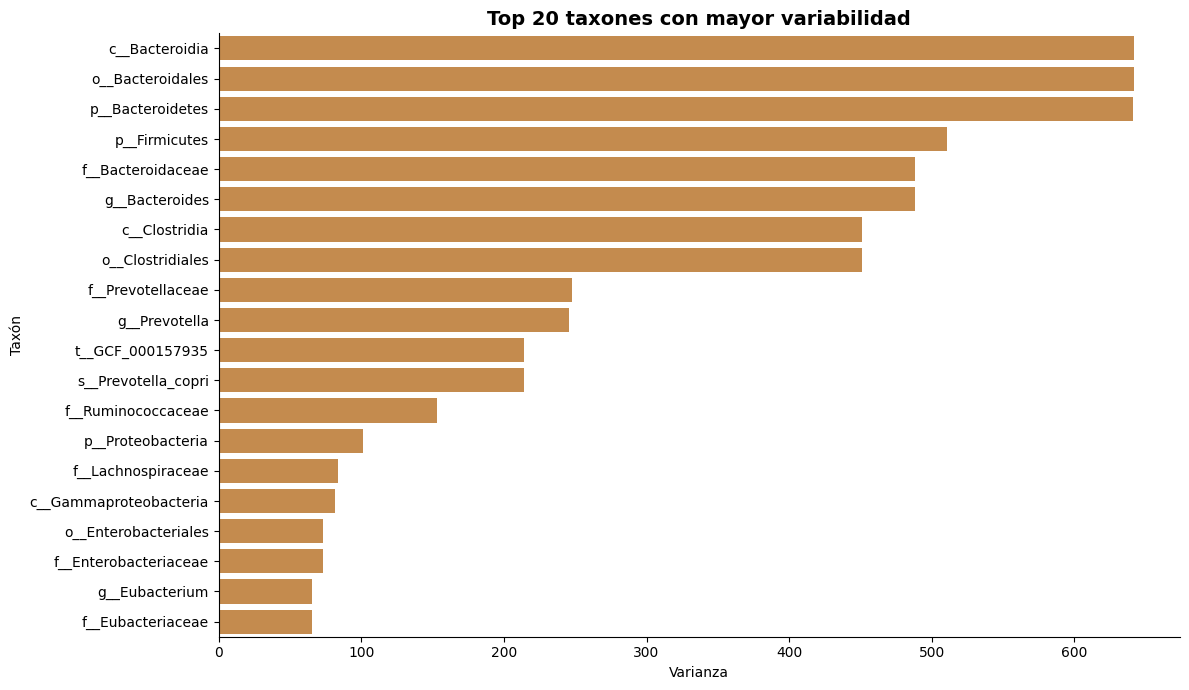

In [47]:
# Grafico
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top_variable_taxa_plot,
    x="variance",
    y="taxon_short",
    color=project_palette["accent"]
)

plt.title("Top 20 taxones con mayor variabilidad", fontsize=14, fontweight="bold")
plt.xlabel("Varianza")
plt.ylabel("Taxón")

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/top20_taxones_variables.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Los taxones con mayor abundancia media no son necesariamente los más útiles para diferenciar grupos clínicos. Por ello, también se analizaron los taxones con mayor variabilidad entre muestras, ya que podrían aportar más información para segmentación, PCA o modelado supervisado.

### 6.6. Agregar taxones por nivel taxonómico

In [48]:
# Función para agregar taxones por nivel taxonómico
def extract_tax_level(taxon_name, level="p__"):
    parts = taxon_name.split("|")
    for part in parts:
        if part.startswith(level):
            return part
    return "unknown"

In [49]:
# Función para agregar abundancias
def aggregate_taxa_by_level(df_taxa, level="p__"):
    grouped_taxa_names = [
        extract_tax_level(col, level=level)
        for col in df_taxa.columns
    ]

    df_grouped = df_taxa.T.groupby(grouped_taxa_names).sum().T

    if "unknown" in df_grouped.columns:
        df_grouped = df_grouped.drop(columns=["unknown"])

    return df_grouped

In [50]:
# Aplicado a filo y clase
X_phylum = aggregate_taxa_by_level(X_taxa, level="p__")
X_class = aggregate_taxa_by_level(X_taxa, level="c__")

print("Taxones originales:", X_taxa.shape[1])
print("Filos:", X_phylum.shape[1])
print("Clases:", X_class.shape[1])

Taxones originales: 2128
Filos: 23
Clases: 38


## 7. Composición microbiana agregada por enfermedad

*X_class* agrupa los taxones por clase bacteriana. 
<br>
**Objetivo**: comparar la **abundancia media** de cada clase entre enfermedades.
<br>
* Ver como cada bacteria cambia entre enfermedades.

### 7.1. Patrones relativos de abundancia por clase bacteriana y condición clínica

In [51]:
# Unir "X_class" con "disease"
X_class_with_disease = X_class.copy()
X_class_with_disease["disease"] = df_eda["disease"].values

In [52]:
# Calcular la abundancia media por enfermedad
mean_class_by_disease = (
    X_class_with_disease
    .groupby("disease")
    .mean()
)

In [53]:
# Transponer datos
heatmap_data = mean_class_by_disease.T
# filas = clases bacterianas
# columnas = enfermedades

In [54]:
# Seleccionar las clases bacterianas más variables entre enfermedades
top_n_classes = 25

top_variable_classes = (
    heatmap_data
    .var(axis=1)        # Calcula la varianza de cada clase entre enfermedades
    .sort_values(ascending=False)
    .head(top_n_classes)
    .index
)

heatmap_data_top = heatmap_data.loc[top_variable_classes]

In [55]:
# Normalizar datos (por fila) para observar patrones relativos
heatmap_data_scaled = heatmap_data_top.sub(
    heatmap_data_top.mean(axis=1),
    axis=0
)

heatmap_data_scaled = heatmap_data_scaled.div(
    heatmap_data_top.std(axis=1),
    axis=0
)

heatmap_data_scaled = heatmap_data_scaled.fillna(0)

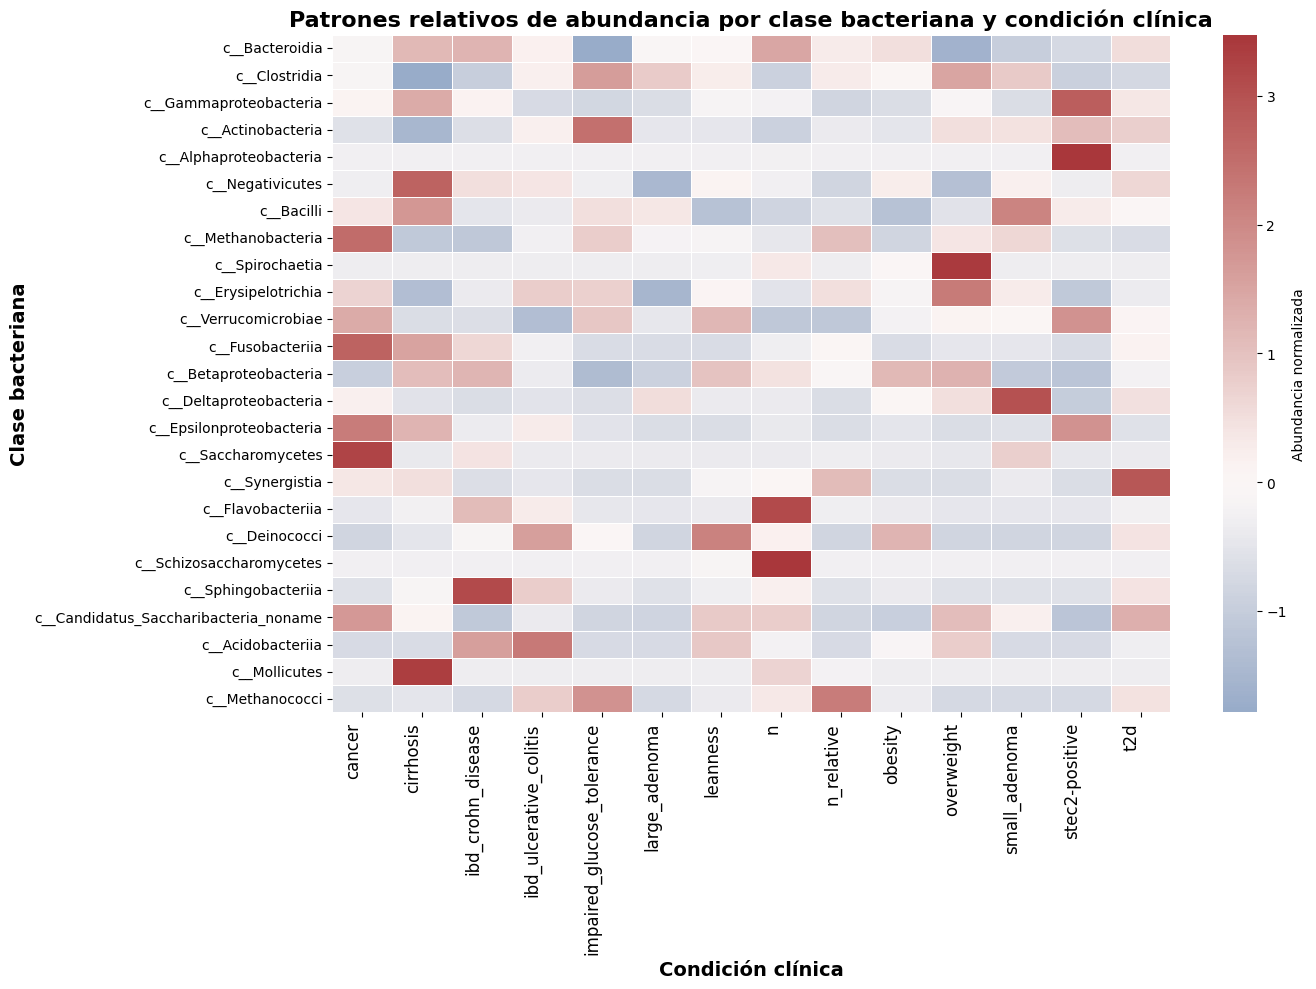

In [56]:
# Gráfico
plt.figure(figsize=(14, 10))

sns.heatmap(
    heatmap_data_scaled,
    cmap="vlag",
    center=0,
    linewidths=0.4,
    cbar_kws={"label": "Abundancia normalizada"}
)

plt.title(
    "Patrones relativos de abundancia por clase bacteriana y condición clínica",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Condición clínica", fontsize=14, fontweight="bold")
plt.ylabel("Clase bacteriana", fontsize=14, fontweight="bold")
plt.xticks(rotation=90, ha="right", fontsize=12)

plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/heatmap_clases_por_enfermedad.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

* Filas = clases bacterianas
* Columnas = condiciones clínicas / `disease`
* Color = abundancia media normalizada

**Cada celda representa**:
Para esta clase bacteriana, *¿la abundancia media en esta enfermedad está por encima o por debajo del promedio de esa misma clase entre todas las enfermedades?*

* Rojo = más abundante que el promedio de esa clase bacteriana.
<br>
* Azul = menos abundante que el promedio de esa clase bacteriana.
<br>
* Blanco = parecido al promedio.

<u>Interpretación por **fila**</u>: mirando una clase bacteriana en particular
<br>
¿En qué enfermedades aparece más alta o más baja esta clase?
<br>
*Ejemplo*: *c__Bacilli* está más alta en **obesity** y más baja en **n**.
<br>
* Eso sugiere un patrón diferencial.

<u>Interpretación por **columna**</u>: mirando una enfermedad en particular
<br>
¿Qué clases bacterianas tienden a estar más altas o más bajas en esta condición?
<br>
*Ejemplo*: *t2d* muestra valores altos en algunas clases y bajos en otras.
<br>
* Eso sugiere un perfil microbiano característico.

#### **Conclusiones**:

* Se observan diferencias relativas en la composición microbiana media entre condiciones clínicas.
* Algunas clases bacterianas muestran patrones de abundancia distintos entre grupos.
* Estos patrones justifican continuar con análisis de reducción dimensional y modelos supervisados.
El heatmap muestra la *abundancia media normalizada* de las clases bacterianas más variables entre condiciones clínicas. Los valores se normalizaron por fila, por lo que los colores representan diferencias relativas respecto al promedio de cada clase bacteriana. Se observan *patrones diferenciados* entre algunas condiciones, lo que sugiere que <u>la composición del microbioma podría contener señal útil para análisis predictivo posterior</u>.

### 7.2. Comparación frente al grupo sano

In [57]:
# Comprobar que "n" está en las columnas
"n" in heatmap_data_top.columns

True

In [58]:
# Calcular diferencias frente a "n"
healthy_reference = heatmap_data_top["n"]

heatmap_vs_healthy = heatmap_data_top.sub(
    healthy_reference,
    axis=0
)

In [59]:
# Eliminar la columna "n"
heatmap_vs_healthy = heatmap_vs_healthy.drop(columns="n")

Toma la abundancia media de cada clase bacteriana en "n". 
Resta ese valor a todas las enfermedades.
Resultado:
- 0: igual que sanos
- positivo: más abundante que sanos
- negativo: menos abundante que sanos

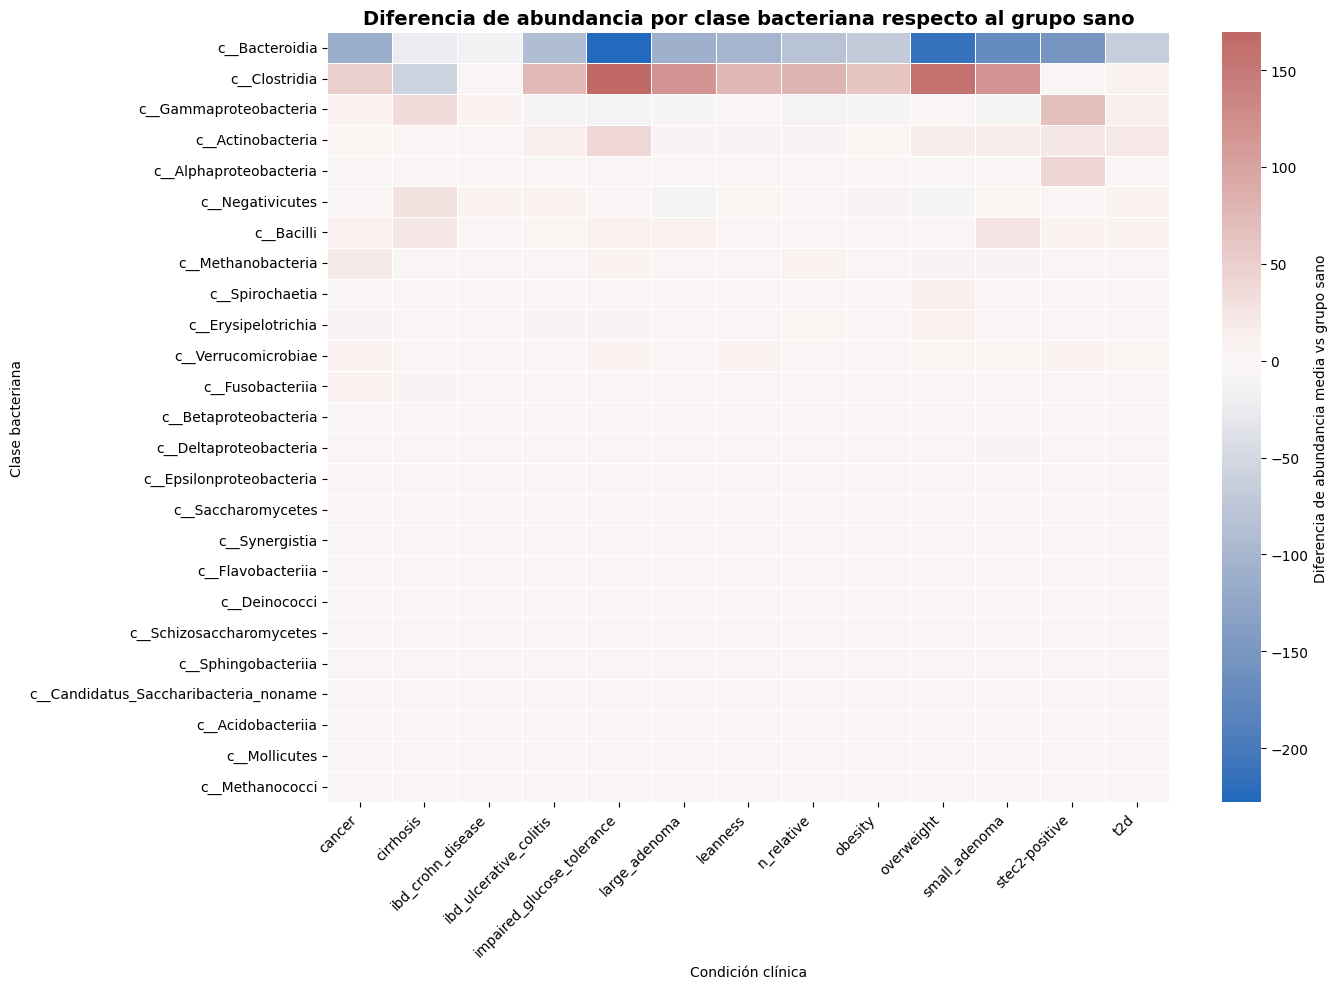

In [60]:
# Gráfico
plt.figure(figsize=(14, 10))

sns.heatmap(
    heatmap_vs_healthy,
    cmap="vlag",
    center=0,
    linewidths=0.4,
    cbar_kws={"label": "Diferencia de abundancia media vs grupo sano"}
)

plt.title(
    "Diferencia de abundancia por clase bacteriana respecto al grupo sano",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Condición clínica")
plt.ylabel("Clase bacteriana")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/heatmap_clases_vs_sano.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Este heatmap compara la abundancia media de las clases bacterianas más variables frente al grupo sano (`n`). Los valores positivos indican mayor abundancia media que en controles, mientras que los valores negativos indican menor abundancia media. Esta visualización permite identificar patrones diferenciales de composición microbiana entre condiciones clínicas y ayuda a orientar la selección de posibles objetivos predictivos.

## 8. PCA del microbioma

**Objetivo**:
<br>
Ver si las muestras se agrupan según enfermedad o según variables de metadata como dataset, país, género o BMI.

In [61]:
# Crear matriz solo con columnas taxonómicas
X_taxa_pca = df_eda[taxa_cols].copy()

In [62]:
# Transformación logarítmica (para evitar sesgo de las abundancias)
# Reduce el impacto de valores muy altos
X_taxa_log = np.log1p(X_taxa_pca)

In [63]:
# Escalar
X_taxa_scaled = StandardScaler().fit_transform(X_taxa_log)

In [64]:
# Calcular PCA con 2 componentes para visualizar
# Reduce las 2128 variables taxonómicas a 2 componentes
pca_2d = PCA(n_components=2, random_state=42)

X_pca_2d = pca_2d.fit_transform(X_taxa_scaled)

In [65]:
# Dataframe para graficar
pca_df = pd.DataFrame({
    "PC1": X_pca_2d[:, 0],
    "PC2": X_pca_2d[:, 1],
    "disease": df_eda["disease"].values,
    "dataset_name": df_eda["dataset_name"].values,
    "country": df_eda["country"].values,
    "gender": df_eda["gender"].values,
    "bmi": df_eda["bmi"].values,
    "age": df_eda["age"].values
})

In [66]:
# Calculo de la varianza explicada
explained_variance = pca_2d.explained_variance_ratio_ * 100

explained_variance

array([5.52399951, 2.50795461])

Las dos primeras componentes principales explican aproximadamente el **8.03%** de la varianza total del perfil taxonómico (PC1: 5.52%, PC2: 2.51%). <u>Este porcentaje relativamente bajo es esperable en datos de microbioma de alta dimensionalidad</u>, donde la variabilidad suele estar **distribuida entre muchas variables**. Por tanto, el PCA 2D se interpreta como una **herramienta exploratoria visual**, no como una representación completa de toda la estructura del dataset.

### 8.1. Límites de zoom para PCA usando percentiles

In [ ]:
# Límites de zoom para PCA usando percentiles

pc1_min, pc1_max = pca_df["PC1"].quantile([0.01, 0.99]) # Calcula el percentil 1 y 99 de PC1
pc2_min, pc2_max = pca_df["PC2"].quantile([0.01, 0.99]) # Calcula el percentil 1 y 99 de PC2

# Definir un rango que excluya los outliers más extremos visualmente.
# No elimina datos del dataframe; SOLO LIMITA LO QUE SE MUESTRA EN EL GRÁFICO.

Se generaron versiones con zoom central de los PCA usando límites entre los percentiles 1 y 99 de PC1 y PC2. Esta visualización no elimina muestras del análisis, sino que permite observar mejor la estructura principal de los datos sin que unos pocos outliers extremos dominen la escala.

### 8.2. PCA coloreado por `disease`: señal clínica

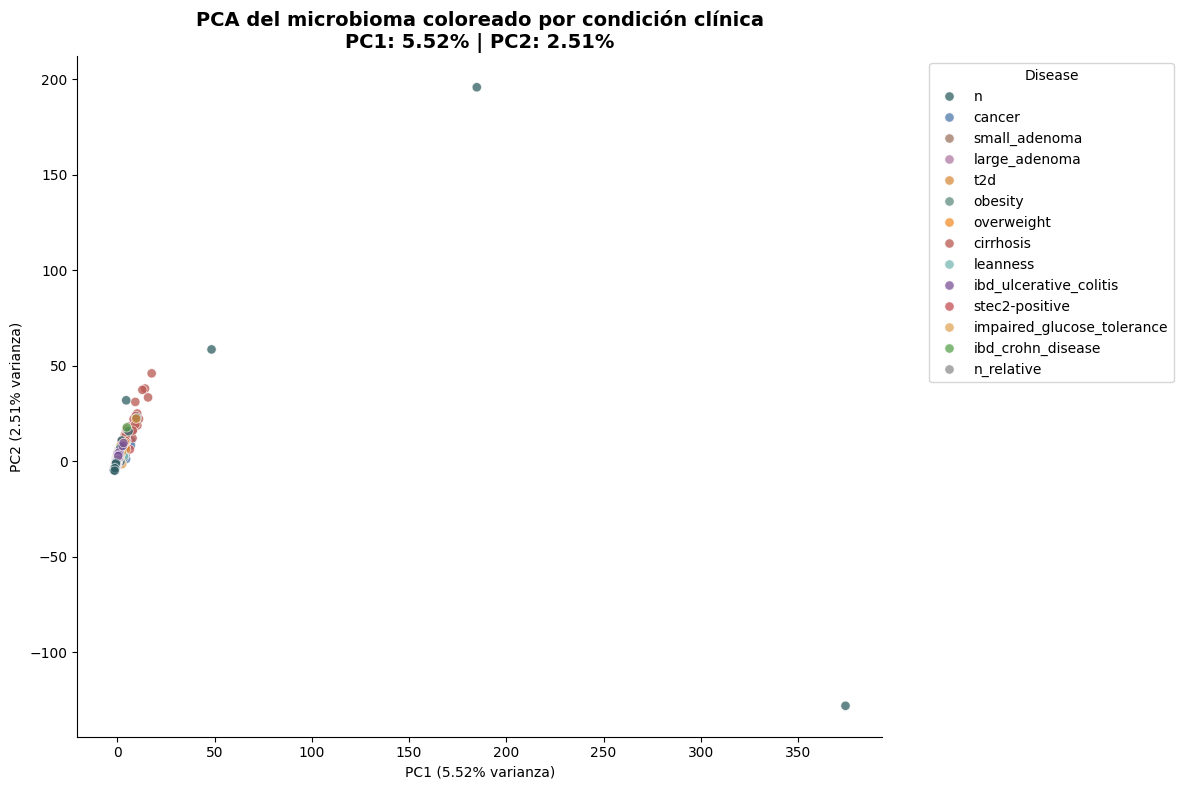

In [68]:
# Gráfico
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="disease",
    palette=disease_palette,
    alpha=0.75,
    s=45
)

plt.title(
    f"PCA del microbioma coloreado por condición clínica\n"
    f"PC1: {explained_variance[0]:.2f}% | PC2: {explained_variance[1]:.2f}%",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(f"PC1 ({explained_variance[0]:.2f}% varianza)")
plt.ylabel(f"PC2 ({explained_variance[1]:.2f}% varianza)")

plt.legend(
    title="Disease",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/pca_microbioma_disease.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

El PCA coloreado por condición clínica permite explorar si las muestras tienden a agruparse según `disease`. Las dos primeras componentes explican aproximadamente el 8.03% de la varianza total, por lo que la visualización debe interpretarse como una aproximación exploratoria. La ausencia de separación clara en PC1/PC2 no descartaría señal predictiva, ya que esta puede encontrarse en componentes posteriores o en relaciones no lineales.

#### 8.2.1. PCA - zoom por `disease`

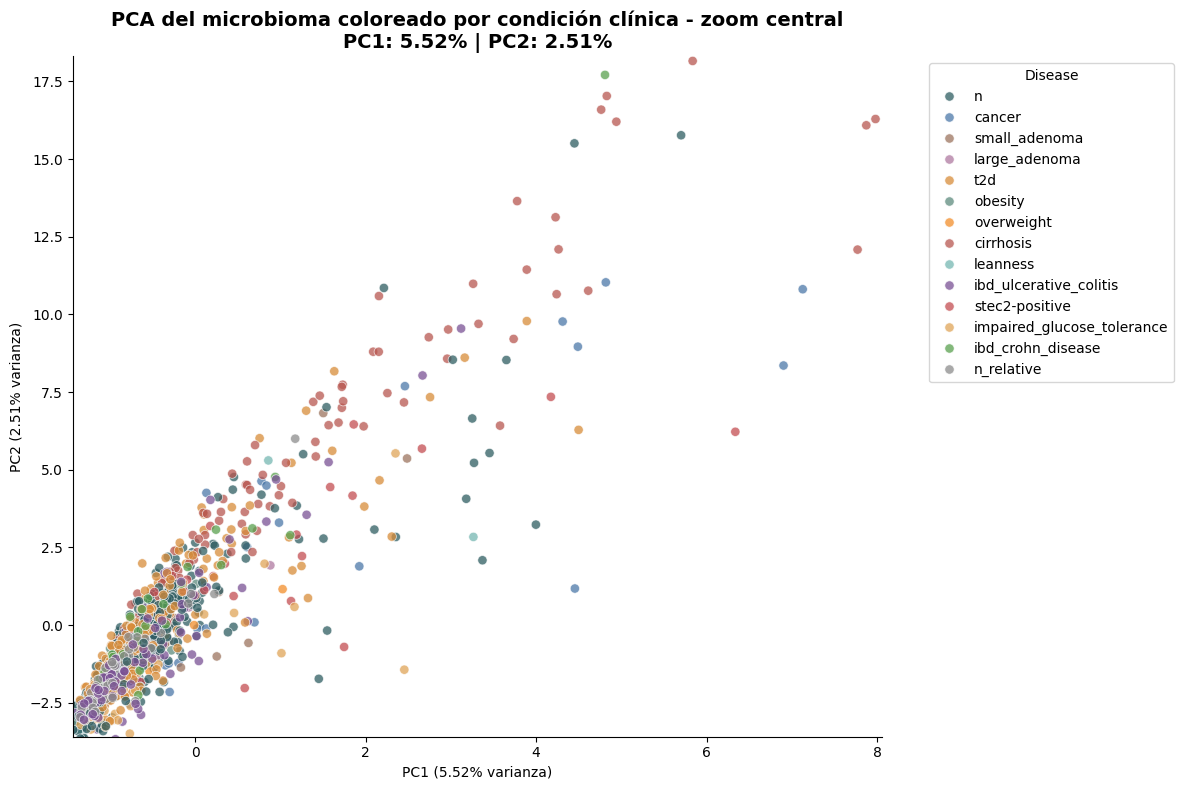

In [ ]:
# Gráfico
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="disease",
    palette=disease_palette,
    alpha=0.75,
    s=45
)

plt.xlim(pc1_min, pc1_max)
plt.ylim(pc2_min, pc2_max)

plt.title(
    f"PCA del microbioma coloreado por condición clínica - zoom central\n"
    f"PC1: {explained_variance[0]:.2f}% | PC2: {explained_variance[1]:.2f}%",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(f"PC1 ({explained_variance[0]:.2f}% varianza)")
plt.ylabel(f"PC2 ({explained_variance[1]:.2f}% varianza)")

plt.legend(
    title="Disease",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/pca_microbioma_disease_zoom.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

No se observa una separación clara y lineal entre todas las condiciones clínicas en PC1/PC2. Sin embargo, algunas clases muestran cierta tendencia a ocupar regiones específicas, lo que justifica explorar objetivos más acotados y modelos supervisados no lineales.

### 8.3. PCA coloreado por `dataset_name`: posible sesgo por estudio

In [69]:
# PCA coloreado por dataset de origen

dataset_counts = df_eda["dataset_name"].value_counts()

top_n_datasets = 10
top_datasets = dataset_counts.head(top_n_datasets).index.tolist()

pca_df["dataset_plot"] = pca_df["dataset_name"].where(
    pca_df["dataset_name"].isin(top_datasets),
    "other"
)

In [70]:
# Definir paleta de colores
dataset_palette_base = [
    project_palette["primary"],
    project_palette["secondary"],
    project_palette["accent"],
    project_palette["danger"],
    "#7A5195",
    "#4C78A8",
    "#76B7B2",
    "#E0A458",
    "#9C755F",
    "#59A14F"
]

dataset_palette = {
    dataset: color
    for dataset, color in zip(top_datasets, dataset_palette_base)
}

dataset_palette["other"] = "#9CA3AF"

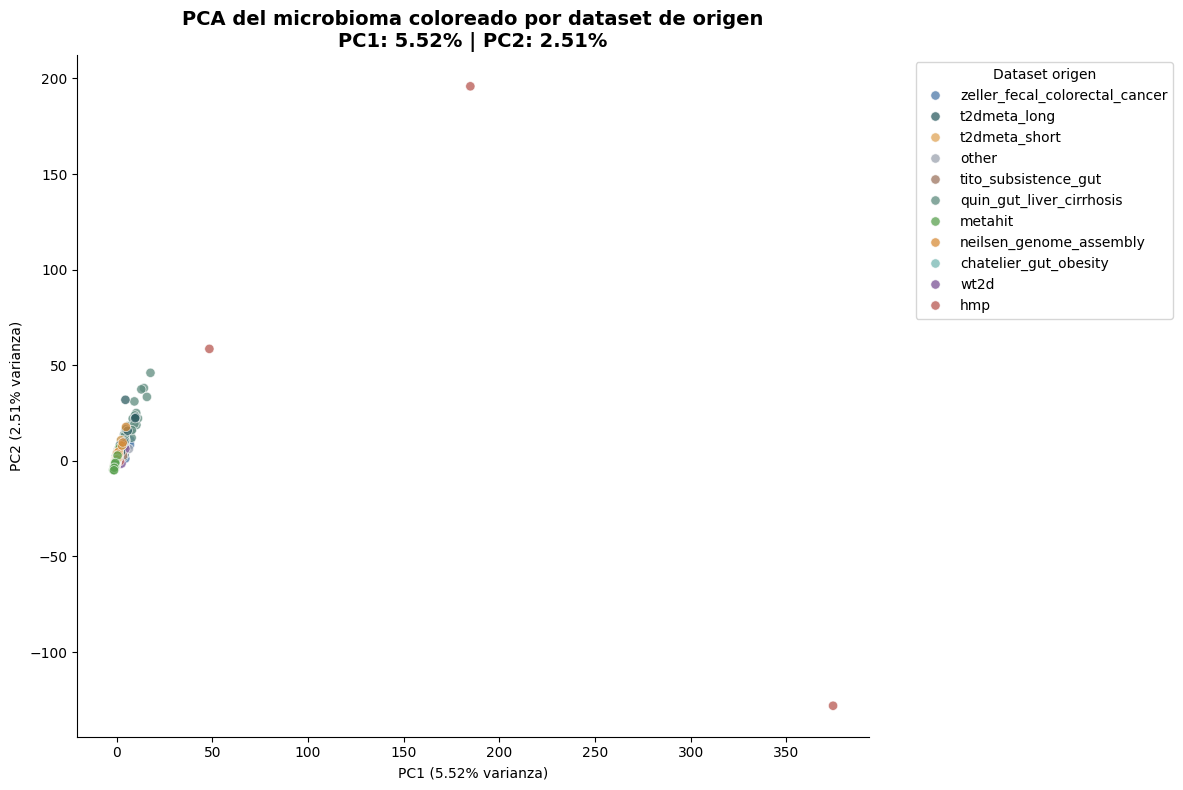

In [71]:
# Gráfico
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="dataset_plot",
    palette=dataset_palette,
    alpha=0.75,
    s=45
)

plt.title(
    f"PCA del microbioma coloreado por dataset de origen\n"
    f"PC1: {explained_variance[0]:.2f}% | PC2: {explained_variance[1]:.2f}%",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(f"PC1 ({explained_variance[0]:.2f}% varianza)")
plt.ylabel(f"PC2 ({explained_variance[1]:.2f}% varianza)")

plt.legend(
    title="Dataset origen",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/pca_microbioma_dataset.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

El PCA coloreado por dataset de origen permite evaluar si la variabilidad global del microbioma está influida por el estudio o fuente original de las muestras. Si se observan agrupamientos claros por `dataset_name`, esto puede indicar un posible efecto de lote o confounding por estudio, aspecto que deberá considerarse al definir el target y al evaluar los modelos.

#### 8.3.1. PCA - zoom por `dataset_name`

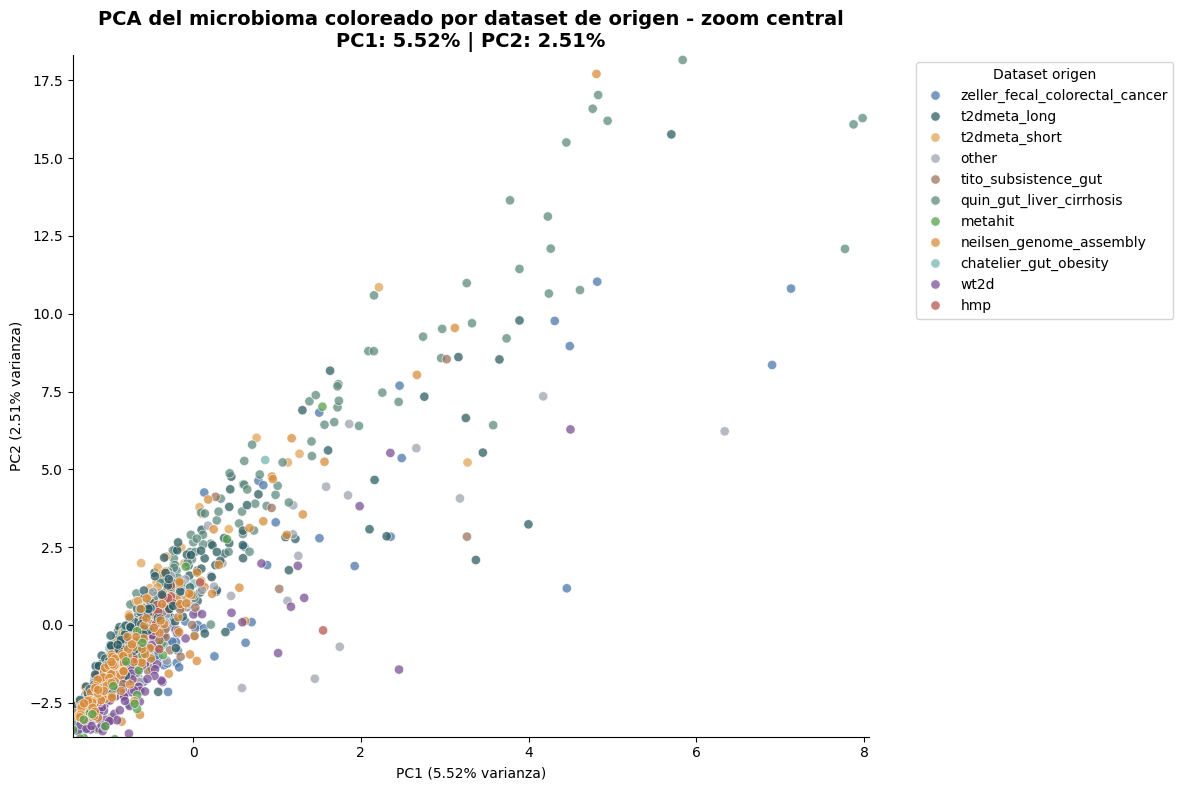

In [76]:
# Gráfico
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="dataset_plot",
    palette=dataset_palette,
    alpha=0.75,
    s=45
)

plt.xlim(pc1_min, pc1_max)
plt.ylim(pc2_min, pc2_max)

plt.title(
    f"PCA del microbioma coloreado por dataset de origen - zoom central\n"
    f"PC1: {explained_variance[0]:.2f}% | PC2: {explained_variance[1]:.2f}%",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(f"PC1 ({explained_variance[0]:.2f}% varianza)")
plt.ylabel(f"PC2 ({explained_variance[1]:.2f}% varianza)")

plt.legend(
    title="Dataset origen",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/pca_microbioma_dataset_zoom.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

La estructura del PCA sugiere posible efecto de dataset de origen. Esto indica que el estudio/fuente de los datos podría influir en la variabilidad del microbioma y debe considerarse como posible factor de confusión.

### 8.4. PCA coloreado por `bmi`: posible gradiente metabólico

In [ ]:
# PCA coloreado por BMI
# BMI es numérica y tiene valores nulos, usaré una paleta continua y dejaré fuera las muestras sin BMI para este gréfico.

pca_bmi_df = pca_df[pca_df["bmi"].notna()].copy()

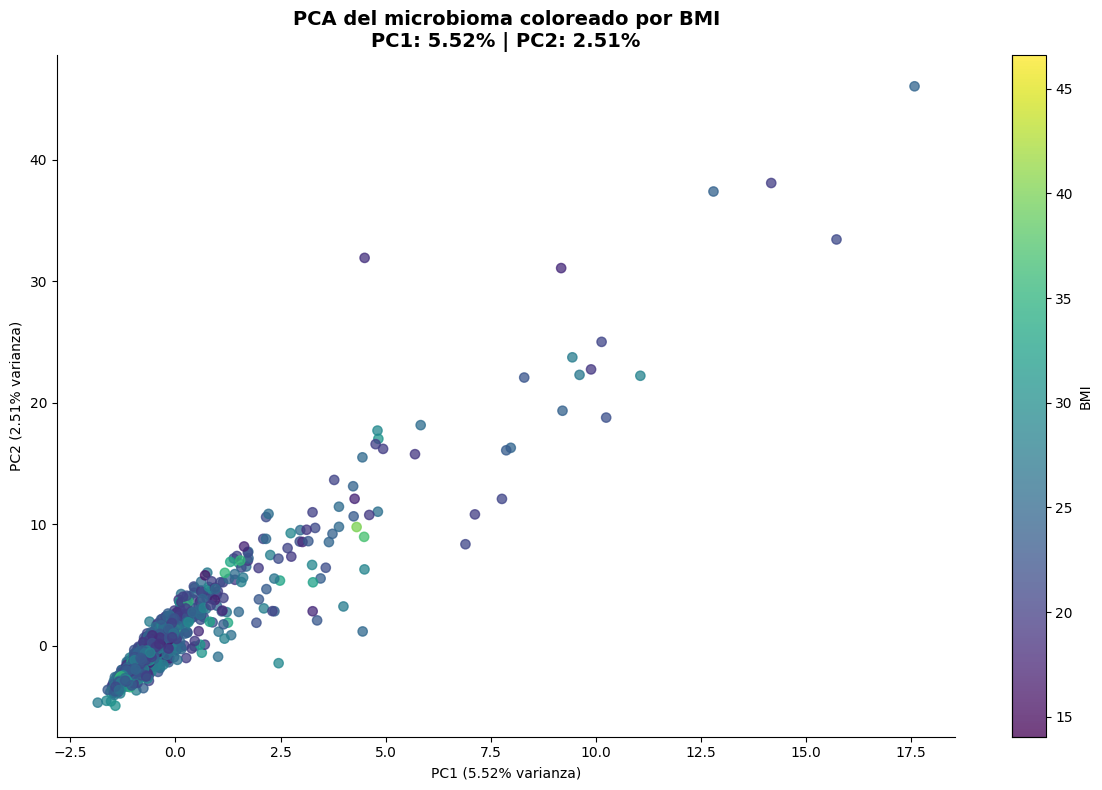

In [73]:
# Gráfico
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    pca_bmi_df["PC1"],
    pca_bmi_df["PC2"],
    c=pca_bmi_df["bmi"],
    cmap="viridis",
    alpha=0.75,
    s=45
)

cbar = plt.colorbar(scatter)
cbar.set_label("BMI")

plt.title(
    f"PCA del microbioma coloreado por BMI\n"
    f"PC1: {explained_variance[0]:.2f}% | PC2: {explained_variance[1]:.2f}%",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(f"PC1 ({explained_variance[0]:.2f}% varianza)")
plt.ylabel(f"PC2 ({explained_variance[1]:.2f}% varianza)")

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/pca_microbioma_bmi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

El PCA coloreado por BMI permite explorar si existe un gradiente metabólico asociado a la composición global del microbioma. Dado que BMI contiene valores faltantes, esta visualización se realizó únicamente con muestras que disponen de BMI válido. La presencia de un gradiente visual sugeriría una posible relación entre composición microbiana y estado metabólico, aunque esta observación debe confirmarse posteriormente con modelos supervisados o análisis específicos.

#### 8.4.1. PCA - zoom por `bmi`

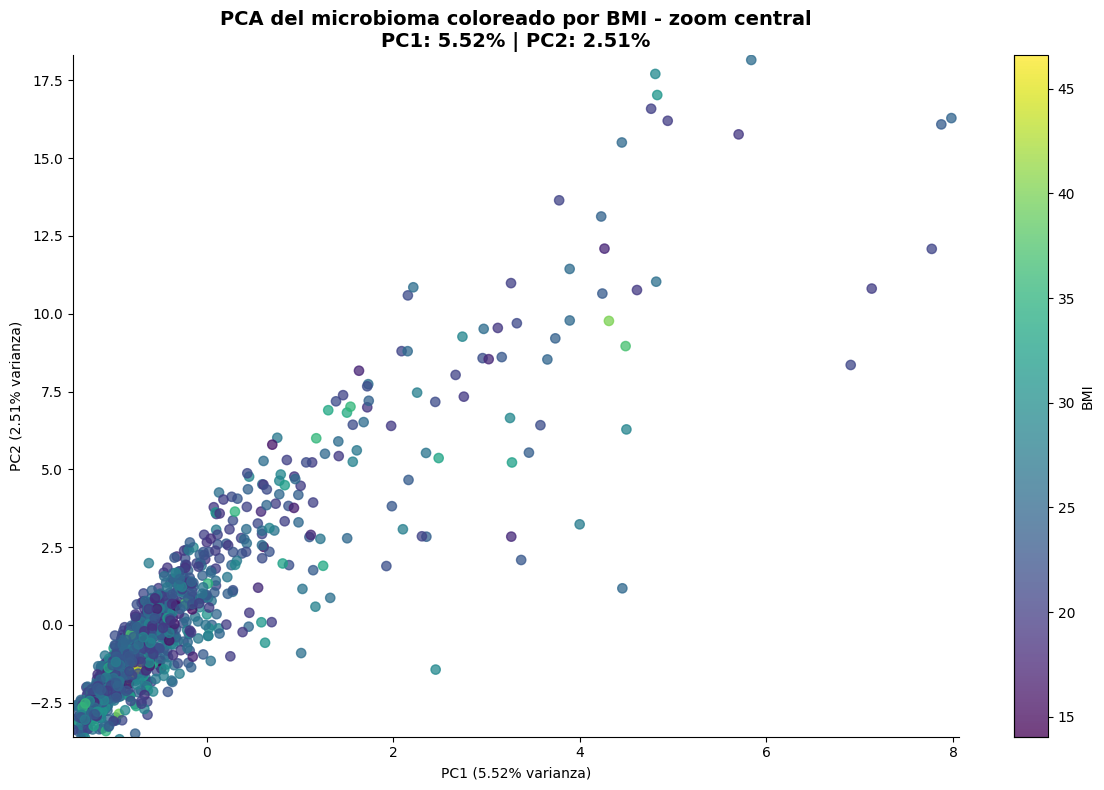

In [77]:
# Gráfico
pca_bmi_df = pca_df[pca_df["bmi"].notna()].copy()

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    pca_bmi_df["PC1"],
    pca_bmi_df["PC2"],
    c=pca_bmi_df["bmi"],
    cmap="viridis",
    alpha=0.75,
    s=45
)

plt.xlim(pc1_min, pc1_max)
plt.ylim(pc2_min, pc2_max)

cbar = plt.colorbar(scatter)
cbar.set_label("BMI")

plt.title(
    f"PCA del microbioma coloreado por BMI - zoom central\n"
    f"PC1: {explained_variance[0]:.2f}% | PC2: {explained_variance[1]:.2f}%",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(f"PC1 ({explained_variance[0]:.2f}% varianza)")
plt.ylabel(f"PC2 ({explained_variance[1]:.2f}% varianza)")

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/pca_microbioma_bmi_zoom.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

No se observa una separación evidente de las muestras por BMI en las dos primeras componentes principales. Puede existir señal metabólica en dimensiones posteriores o en relaciones no lineales, pero PC1 y PC2 no muestran un gradiente fuerte.

### 8.5. Conclusión general PCAs

1. El microbioma tiene estructura, pero no una separación clínica simple.
2. PC1/PC2 explican solo el 8.03%, así que no debemos sobreinterpretar.
3. Hay señales de posible efecto de dataset de origen.
4. Para modelado conviene acotar el target, controlar sesgos y probar modelos no lineales.

Los PCA con zoom central muestran una estructura continua del microbioma, sin separación clínica clara en las dos primeras componentes. La coloración por `dataset_name` sugiere posible efecto de estudio de origen, mientras que la coloración por BMI no evidencia un gradiente marcado. 
<br>
Dado que PC1 y PC2 explican conjuntamente alrededor del 8.03% de la varianza, estos resultados se interpretan como **exploratorios** y justifican continuar con **modelos supervisados** y posibles estrategias de selección/reducción de variables.

## 9. Notas finales del EDA

### 9.1. Conclusiones del EDA

A partir del análisis exploratorio del dataset limpio, se identificaron varios puntos relevantes para la fase de **modelado**:

1. **Dataset viable y suficientemente complejo**  
   El dataset limpio conserva **1577 muestras únicas** y **2128 variables taxonómicas**, por lo que cumple los requisitos mínimos del proyecto y ofrece suficiente complejidad para aplicar **técnicas de machine learning**.

2. **Variable clínica disponible, pero desbalanceada**  
   La columna `disease` contiene varias condiciones clínicas, con predominio de la clase `n`. Algunas clases tienen pocos registros, por lo que no todas son adecuadas como objetivo principal de modelado.

3. **Alta dimensionalidad y sparsity**  
   Muchas variables taxonómicas contienen un porcentaje elevado de ceros, lo que indica que numerosos taxones aparecen en pocas muestras. Esto justifica considerar filtrado por prevalencia, agregación taxonómica, selección de variables o reducción dimensional.

4. **Patrones microbianos exploratorios**  
   Los heatmaps agregados por clase bacteriana muestran diferencias relativas en la composición microbiana entre condiciones clínicas, aunque estas diferencias deben interpretarse como **descriptivas** y **no causales**.

5. **PCA exploratorio**  
   Las dos primeras componentes principales explican aproximadamente el 8.03% de la varianza total. No se observa una separación clínica clara en PC1/PC2, pero sí una estructura continua y posibles diferencias por dataset de origen.

6. **Posible efecto de dataset de origen**  
   El PCA coloreado por `dataset_name` sugiere que la fuente original de las muestras puede influir en la variabilidad del microbioma. Esto deberá considerarse como posible factor de confusión durante el modelado.

7. **Necesidad de acotar el problema predictivo**  
   Dado el desbalance de clases, la alta dimensionalidad y la posible influencia del dataset de origen, el primer objetivo supervisado debería ser acotado y clínicamente interpretable.

### 9.2. Decisiones para la fase de modelado

A partir del EDA, se propone iniciar la fase de modelado con un **enfoque supervisado acotado**.

*Objetivo principal candidato:*

- Clasificación binaria entre controles (`n`) y diabetes tipo 2 (`t2d`).

*Objetivos secundarios posibles:*

- Clasificación binaria `n` vs `obesity`.
- Clasificación multiclase acotada entre condiciones metabólicas.
- Análisis exploratorio de la relación entre microbioma y BMI.

*Estrategias técnicas a evaluar:*

- Filtrado de taxones poco prevalentes.
- Agregación taxonómica por clase o filo para análisis interpretables.
- PCA como técnica de reducción dimensional.
- Comparación de modelos lineales y no lineales.

**Nota metodológica importante:**
Las transformaciones como escalado, PCA o selección de variables deberán ajustarse únicamente con el **conjunto de entrenamiento** durante la fase de modelado, para evitar fuga de información hacia el conjunto de test.